# Model Training

In this section, we prepare the dataset for machine learning by selecting the input features and target variable, preprocessing the data, training multiple regression models, and evaluating their performance.

The objective is to identify the model that best predicts students' Mathematics scores.

In [7]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings

In [8]:
df = pd.read_csv("study.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
columns = [
    "gender",
    "race_ethnicity",
    "parental_level_of_education",
    "lunch",
    "test_preparation_course"
]

for col in columns:
    print(f"Categories in '{col}' variable: {df[col].unique()}\n")

Categories in 'gender' variable: <StringArray>
['female', 'male']
Length: 2, dtype: str

Categories in 'race_ethnicity' variable: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

Categories in 'parental_level_of_education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

Categories in 'lunch' variable: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

Categories in 'test_preparation_course' variable: <StringArray>
['none', 'completed']
Length: 2, dtype: str



## Define Features and Target

The objective of this project is to predict students' **Mathematics Score**.

Therefore,

- **Features (X)** consist of the remaining independent variables.
- **Target (y)** is the Mathematics Score.

In [10]:
# ============================================================
# Define Features (X) and Target (y)
# ============================================================

# Input Features
X = df.drop(columns=["math_score"])

# Target Variable
y = df["math_score"]

# Display the first five rows of input features
display(X.head())

# Display the first five target values
display(y.head())

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

## Train-Test Split

Split the dataset into training and testing sets.

- **80%** of the data is used for training.
- **20%** of the data is reserved for testing.

This helps evaluate the model's performance on unseen data.

In [11]:
# ============================================================
# Import Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# ============================================================
# Split the Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shape of each dataset
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (800, 7)
Testing Features  : (200, 7)
Training Target   : (800,)
Testing Target    : (200,)


## Identify Numerical and Categorical Features

Before preprocessing, separate the input features into numerical and categorical columns.

This allows us to apply different preprocessing techniques to each type of feature.

In [12]:
# ============================================================
# Identify Numerical and Categorical Features
# ============================================================

# Select numerical columns
num_features = X_train.select_dtypes(include=["number"]).columns

# Select categorical columns
cat_features = X_train.select_dtypes(include=["object", "string"]).columns

# Display numerical features
print("Numerical Features")
print("-" * 50)
print(list(num_features))

# Display categorical features
print("\nCategorical Features")
print("-" * 50)
print(list(cat_features))

Numerical Features
--------------------------------------------------
['reading_score', 'writing_score']

Categorical Features
--------------------------------------------------
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


## Import Preprocessing Libraries

Import the preprocessing tools required to transform numerical and categorical features before model training.

In [13]:
# ============================================================
# Import Preprocessing Libraries
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Create the Preprocessing Pipeline

Create separate preprocessing pipelines for numerical and categorical features and combine them using a ColumnTransformer.

This ensures that each feature type is processed appropriately before model training.

In [14]:
# ============================================================
# Numerical Pipeline
# ============================================================

# Standardize numerical features
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# ============================================================
# Categorical Pipeline
# ============================================================

# One-Hot Encode categorical features
categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# ============================================================
# Combine Both Pipelines
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

# Display the preprocessing pipeline
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Transform the Training and Testing Data

Fit the preprocessing pipeline using only the training data and apply the same transformations to both the training and testing datasets.

This prevents data leakage and ensures a fair evaluation of the model.

In [15]:
# ============================================================
# Apply Preprocessing
# ============================================================

# Fit the preprocessor on the training data and transform it
X_train = preprocessor.fit_transform(X_train)

# Transform the testing data using the fitted preprocessor
X_test = preprocessor.transform(X_test)

# Display the transformed dataset shapes
print("Transformed Training Data :", X_train.shape)
print("Transformed Testing Data  :", X_test.shape)

Transformed Training Data : (800, 19)
Transformed Testing Data  : (200, 19)


## Import Machine Learning Models

Import the regression algorithms that will be trained and evaluated on the dataset.

Using multiple models allows us to compare their performance and identify the best-performing algorithm.

In [16]:
# ============================================================
# Import Regression Models
# ============================================================

from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge
)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.svm import SVR

from xgboost import XGBRegressor

## Import Evaluation Metrics

Import the evaluation metrics used to measure the performance of regression models.

In [17]:
# ============================================================
# Import Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

## Create Model Dictionary

Store all regression models inside a dictionary.

This allows us to train and evaluate every model using a single loop instead of writing repetitive code.

In [18]:
# ============================================================
# Create Model Dictionary
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Lasso Regression": Lasso(),

    "Ridge Regression": Ridge(),

    "K-Nearest Neighbors": KNeighborsRegressor(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "AdaBoost": AdaBoostRegressor(random_state=42),

    "Support Vector Regressor": SVR(),

    "XGBoost": XGBRegressor(random_state=42)
}

# Display the model names
print("Regression Models:\n")

for model_name in models.keys():
    print(model_name)

Regression Models:

Linear Regression
Lasso Regression
Ridge Regression
K-Nearest Neighbors
Decision Tree
Random Forest
Gradient Boosting
AdaBoost
Support Vector Regressor
XGBoost


## Create Evaluation Function

Create a reusable function that calculates the regression evaluation metrics.

This avoids repetitive code and ensures every model is evaluated consistently.

In [19]:
# ============================================================
# Model Evaluation Function
# ============================================================

def evaluate_model(y_true, y_pred):
    """
    Calculate regression evaluation metrics.

    Parameters
    ----------
    y_true : Actual target values

    y_pred : Predicted target values

    Returns
    -------
    MAE, MSE, RMSE, R2 Score
    """

    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)

    # Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)

    # Root Mean Squared Error
    rmse = np.sqrt(mse)

    # R² Score
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

## Train and Evaluate All Models

Train each regression model, evaluate its performance on both the training and testing datasets, and compare their performance.

Evaluating both datasets helps identify:

- Good Fit
- Overfitting
- Underfitting

In [24]:
# ============================================================
# Train and Evaluate All Regression Models
# ============================================================

# Create an empty list to store model performance
model_results = []

# Loop through each regression model
for model_name, model in models.items():

    # --------------------------------------------------------
    # Train the model
    # --------------------------------------------------------
    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    # Predict on training data
    y_train_pred = model.predict(X_train)

    # Predict on testing data
    y_test_pred = model.predict(X_test)

    # --------------------------------------------------------
    # Evaluate Training Performance
    # --------------------------------------------------------

    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(
        y_train,
        y_train_pred
    )

    # --------------------------------------------------------
    # Evaluate Testing Performance
    # --------------------------------------------------------

    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(
        y_test,
        y_test_pred
    )

    # --------------------------------------------------------
    # Determine Model Status
    # --------------------------------------------------------

    r2_difference = train_r2 - test_r2

    if train_r2 < 0.70 and test_r2 < 0.70:
        status = "Underfitting"

    elif r2_difference <= 0.05:
        status = "Good Fit"

    elif r2_difference <= 0.15:
        status = "Slight Overfitting"

    else:
        status = "Overfitting"

    # --------------------------------------------------------
    # Store Results
    # --------------------------------------------------------

    model_results.append({

        "Model": model_name,

        "Train R²": round(train_r2, 4),
        "Test R²": round(test_r2, 4),

        "Train RMSE": round(train_rmse, 4),
        "Test RMSE": round(test_rmse, 4),

        "Train MAE": round(train_mae, 4),
        "Test MAE": round(test_mae, 4),

        "Status": status
    })

In [25]:
# ============================================================
# Create Model Comparison Table
# ============================================================

# Convert results into a DataFrame
results_df = pd.DataFrame(model_results)

# Sort models based on Test R² Score
results_df = results_df.sort_values(
    by="Test R²",
    ascending=False
)

# Reset index
results_df.reset_index(drop=True, inplace=True)

# Display the comparison table
results_df

,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,Status
0,Ridge Regression,0.8743,0.8806,5.3233,5.3904,4.2650,4.2111,Good Fit
1,Linear Regression,0.8743,0.8804,5.3231,5.3940,4.2667,4.2148,Good Fit
2,Gradient Boosting,0.9050,0.8722,4.6269,5.5765,3.7226,4.3038,Good Fit
3,AdaBoost,0.8518,0.8516,5.7803,6.0083,4.7303,4.6813,Good Fit
4,Random Forest,0.9765,0.8504,2.3035,6.0337,1.8249,4.7015,Slight Overfitting
5,Lasso Regression,0.8072,0.8254,6.5925,6.5173,5.2053,5.1557,Good Fit
6,XGBoost,0.9955,0.8212,1.0073,6.5958,0.6875,5.1036,Overfitting
7,K-Nearest Neighbors,0.8559,0.7840,5.6991,7.2506,4.5083,5.5990,Slight Overfitting
8,Decision Tree,0.9997,0.7473,0.2795,7.8409,0.0187,6.2400,Overfitting
9,Support Vector Regressor,0.8084,0.7291,6.5721,8.1191,4.8663,5.3951,Slight Overfitting


In [26]:
# ============================================================
# Display Best Performing Model
# ============================================================

best_model = results_df.iloc[0]

print("=" * 60)
print("Best Performing Model")
print("=" * 60)

print(f"Model Name      : {best_model['Model']}")
print(f"Train R² Score  : {best_model['Train R²']}")
print(f"Test R² Score   : {best_model['Test R²']}")
print(f"Train RMSE      : {best_model['Train RMSE']}")
print(f"Test RMSE       : {best_model['Test RMSE']}")
print(f"Status          : {best_model['Status']}")

Best Performing Model
Model Name      : Ridge Regression
Train R² Score  : 0.8743
Test R² Score   : 0.8806
Train RMSE      : 5.3233
Test RMSE       : 5.3904
Status          : Good Fit


## Compare Model Performance

Visualize the performance of all regression models using their Test R² Scores.

This helps quickly identify the best-performing model.

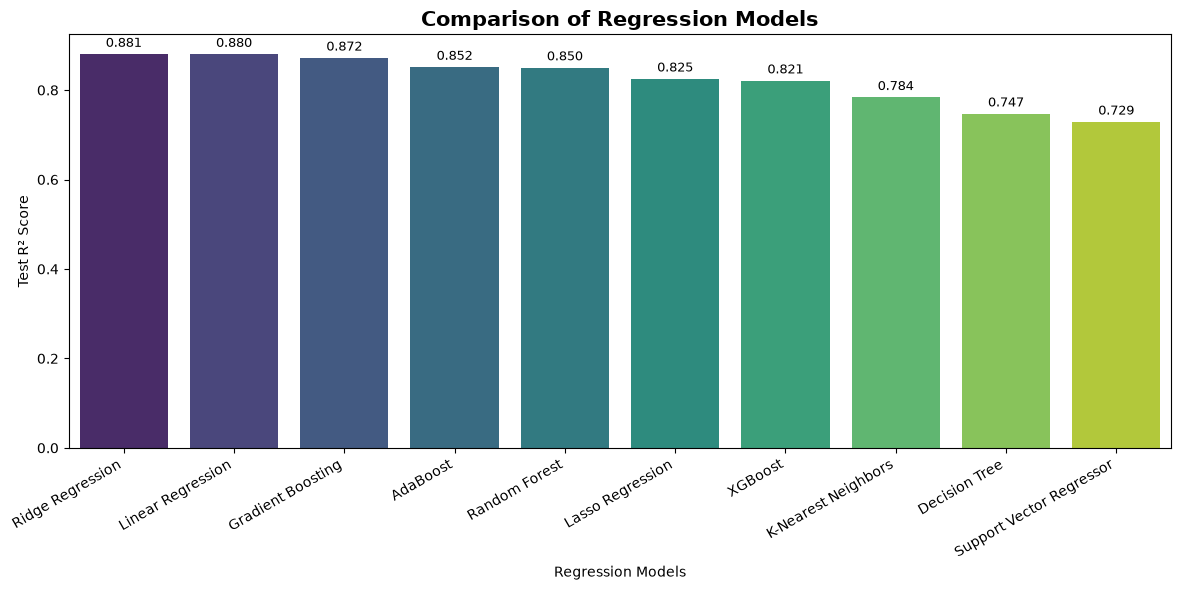

In [28]:
# ============================================================
# Compare Test R² Scores of All Models
# ============================================================

# Create the figure
plt.figure(figsize=(12, 6))

# Draw the bar chart
ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Test R²",
    hue="Model",          # Assign hue
    palette="viridis",
    legend=False          # Hide the unnecessary legend
)

# Display the R² score on each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

# Customize the plot
plt.title(
    "Comparison of Regression Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Regression Models")
plt.ylabel("Test R² Score")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

# Display the plot
plt.show()

In [29]:
# ============================================================
# Select the Best Model
# ============================================================

# Get the best model name
best_model_name = results_df.iloc[0]["Model"]

# Retrieve the trained model
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")

Best Model: Ridge Regression


# Ridge Regression

In [30]:
# ============================================================
# Predict Using the Best Model
# ============================================================

# Predict the target values
y_pred = best_model.predict(X_test)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    "Actual Score": y_test,
    "Predicted Score": y_pred
})

# Display the first 10 predictions
comparison_df.head(10)

,Actual Score,Predicted Score
521,91,76.398746
737,53,58.843165
740,80,76.992035
660,74,76.806200
411,84,87.614981
678,81,78.916374
626,69,64.714615
513,54,53.044540
859,87,74.116489
136,51,49.365132


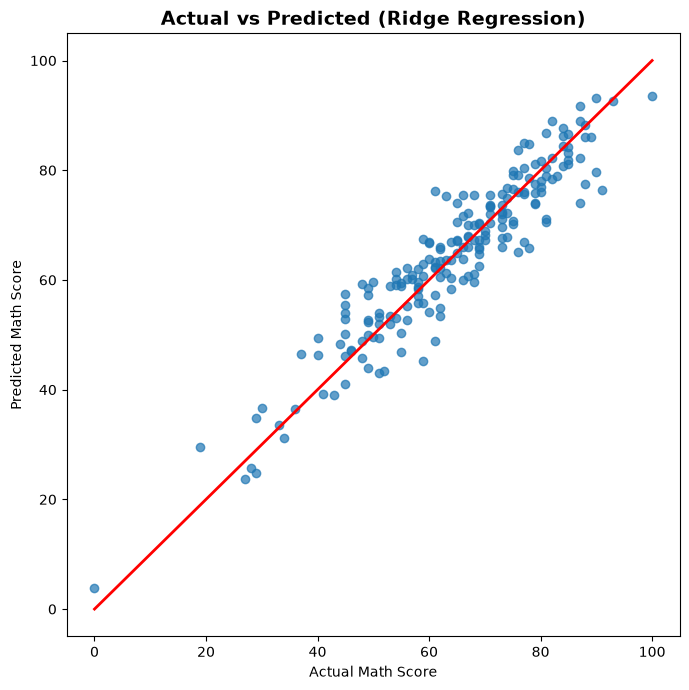

In [31]:
# ============================================================
# Actual vs Predicted Scatter Plot
# ============================================================

plt.figure(figsize=(7, 7))

# Scatter plot
plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

# Customize the plot
plt.title(
    f"Actual vs Predicted ({best_model_name})",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")

plt.tight_layout()

plt.show()

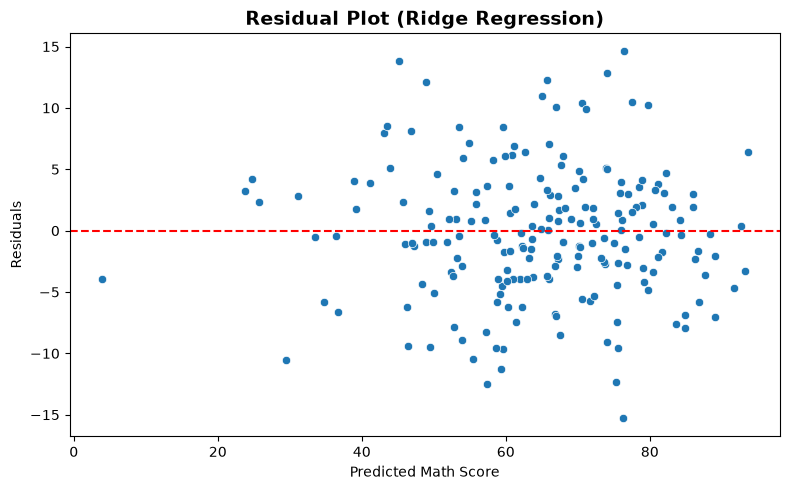

In [32]:
# ============================================================
# Residual Plot
# ============================================================

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

# Residual scatter plot
sns.scatterplot(
    x=y_pred,
    y=residuals
)

# Reference line at zero
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

# Customize the plot
plt.title(
    f"Residual Plot ({best_model_name})",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Math Score")
plt.ylabel("Residuals")

plt.tight_layout()

plt.show()

## Model Training

Multiple regression algorithms were trained and evaluated using the same preprocessing pipeline.

The models were compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Training and testing performance were also compared to identify potential overfitting or underfitting.

Among all the evaluated models, **Ridge Regression** achieved the best balance between prediction accuracy and generalization performance.

---

## Model Evaluation

The Actual vs Predicted scatter plot shows that most predicted values lie close to the ideal 45-degree reference line.

This indicates that the model is able to predict Mathematics scores with good accuracy.

The Residual Plot shows that the prediction errors are randomly distributed around zero without any obvious systematic pattern.

This suggests that:

- The model captures the underlying relationship effectively.
- No major prediction bias is observed.
- The regression assumptions are reasonably satisfied.

---


## Overall Conclusion

The developed machine learning pipeline successfully predicts students' Mathematics scores using demographic and educational features.

The preprocessing pipeline, model comparison framework, and evaluation process provide a robust and reusable workflow for regression problems.

This project demonstrates the complete machine learning lifecycle, including:

- Data Exploration
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Performance Comparison
- Model Interpretation

Overall, the selected model provides reliable predictions and can serve as a useful tool for understanding and estimating student academic performance.